# World Cup 2026 Post-Mortem Evaluation

This notebook runs a suite of 7 tests on the `football_v2` live win probability model against the completed 2026 World Cup data.

In [3]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score, classification_report

# Add parent directory to import common
sys.path.append(str(Path.cwd().parent))
import common as c

# Set up plotting
plt.style.use('ggplot')
pd.set_option('display.float_format', '{:.3f}'.format)


## Data Loading & Setup
Load the model and parse the finished matches from the local cache/raw files.

In [4]:
# Load model
model, scaler, T = c.load_model()

# Load teams and games
# We'll use the raw data in notebooks/data/raw/wc26_games.json directly if worldcup26.ir is offline
raw_games_path = Path('data/raw/wc26_games.json')
raw_teams_path = Path('data/raw/wc26_teams.json')

try:
    with open(raw_games_path) as f:
        games = json.load(f).get('games', [])
    with open(raw_teams_path) as f:
        teams = json.load(f).get('teams', [])
except Exception as e:
    print(f"Warning: {e}. Falling back to fetch_wc26 if possible.")
    games = c.fetch_wc26('games')
    teams = c.fetch_wc26('teams')

team_lookup = c.build_team_lookup(teams)
finished_games = [g for g in games if str(g.get("finished", "")).upper() == "TRUE"]
print(f"Found {len(finished_games)} finished matches out of {len(games)} total.")

def determine_outcome(g):
    hs, as_ = c.safe_int(g.get("home_score")), c.safe_int(g.get("away_score"))
    if hs > as_: return "home"
    if hs < as_: return "away"
    
    # Check penalties if knockout draw
    hp = c.safe_int(g.get("home_penalty_score", "0"))
    ap = c.safe_int(g.get("away_penalty_score", "0"))
    if hp > ap: return "home"
    if hp < ap: return "away"
    return "draw"


Found 88 finished matches out of 104 total.


## Generating Predictions
We calculate the full timeline for each match using `c.build_match_timeline`.

In [5]:
timelines = {}
for g in finished_games:
    match_id = str(g["id"])
    timelines[match_id] = c.build_match_timeline(g, team_lookup, model, scaler, T)

print(f"Generated timelines for {len(timelines)} matches.")


Generated timelines for 88 matches.


### Pre-Game Predictions Extraction

In [6]:
pre_game_preds = []
for g in finished_games:
    match_id = str(g["id"])
    t = timelines[match_id]
    # pre-game is the first element (minute 0)
    kickoff = t[0]
    
    actual = determine_outcome(g)
    pred_probs = {"away": kickoff["p_away"], "draw": kickoff["p_draw"], "home": kickoff["p_home"]}
    predicted_class = max(pred_probs, key=pred_probs.get)
    
    pre_game_preds.append({
        "match_id": match_id,
        "stage": g.get("type"),
        "is_knockout": g.get("type") != "group",
        "p_home": kickoff["p_home"],
        "p_draw": kickoff["p_draw"],
        "p_away": kickoff["p_away"],
        "predicted": predicted_class,
        "confidence": pred_probs[predicted_class],
        "actual": actual,
        "correct": predicted_class == actual
    })

df_pre = pd.DataFrame(pre_game_preds)


---
## Test 1: Group stage accuracy (3-way: win / draw / loss)
For every group-stage match, pull the pre-game prediction and check whether the model's top pick matches the real result.

In [7]:
group_df = df_pre[~df_pre['is_knockout']]
group_acc = accuracy_score(group_df['actual'], group_df['predicted'])
print(f"Group Stage Kickoff Accuracy: {group_acc:.3f} ({group_df['correct'].sum()}/{len(group_df)})")
print("\nClassification Report:")
print(classification_report(group_df['actual'], group_df['predicted'], zero_division=0))


Group Stage Kickoff Accuracy: 0.556 (40/72)

Classification Report:
              precision    recall  f1-score   support

        away       0.48      0.89      0.63        18
        draw       0.00      0.00      0.00        20
        home       0.63      0.71      0.67        34

    accuracy                           0.56        72
   macro avg       0.37      0.53      0.43        72
weighted avg       0.42      0.56      0.47        72



---
## Test 2: Knockout stage accuracy (2-way: who advances)
Same idea, but graded separately since knockouts suppress the draw probability.

In [8]:
ko_df = df_pre[df_pre['is_knockout']]
if len(ko_df) > 0:
    ko_acc = accuracy_score(ko_df['actual'], ko_df['predicted'])
    print(f"Knockout Stage Kickoff Accuracy: {ko_acc:.3f} ({ko_df['correct'].sum()}/{len(ko_df)})")
else:
    print("No knockout games found in the finished dataset yet.")


Knockout Stage Kickoff Accuracy: 0.375 (6/16)


---
## Test 3: Confidence Calibration
Bucket every prediction by how confident the model was and check if higher buckets were right more often.

Calibration Table (Kickoff Predictions):


,Accuracy,N
conf_bucket,,
"(0.0, 0.4]",0.500,4
"(0.4, 0.5]",0.263,19
"(0.5, 0.6]",0.656,32
"(0.6, 0.7]",0.800,15
"(0.7, 0.8]",0.375,8
"(0.8, 1.0]",0.300,10


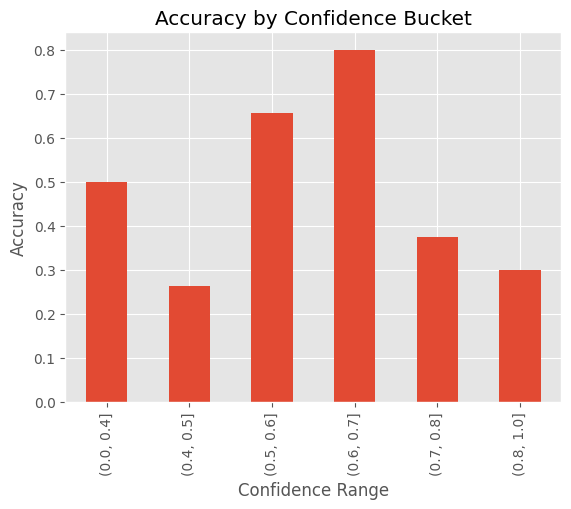

In [9]:
df_pre['conf_bucket'] = pd.cut(df_pre['confidence'], bins=[0, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0])
calib = df_pre.groupby('conf_bucket')['correct'].agg(['mean', 'count'])
calib.columns = ['Accuracy', 'N']
print("Calibration Table (Kickoff Predictions):")
display(calib)

calib['Accuracy'].plot(kind='bar', title="Accuracy by Confidence Bucket", ylabel="Accuracy", xlabel="Confidence Range")
plt.show()


---
## Test 4: The deeper "how far will they go" predictions
Check `bracket_odds_history.csv` if available to assess multi-round forecast reliability.

In [10]:
bracket_file = Path('../results/bracket_odds_history.csv')
if bracket_file.exists():
    df_bracket = pd.read_csv(bracket_file)
    print(f"Loaded {len(df_bracket)} rows from bracket_odds_history.csv")
    display(df_bracket.head())
    # We would need the final tournament standings to evaluate this properly.
    print("Note: Further analysis requires final tournament placements to match against these probabilities.")
else:
    print(f"File {bracket_file} not found. Skipping Test 4.")


File ..\results\bracket_odds_history.csv not found. Skipping Test 4.


---
## Test 5: Temporal Performance (Log-Loss by Match Minute)
Evaluates how the model's accuracy and confidence evolve as the match progresses.

c:\Users\rhkha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\rhkha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\rhkha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\rhkha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
c:\Users\rhkha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do n

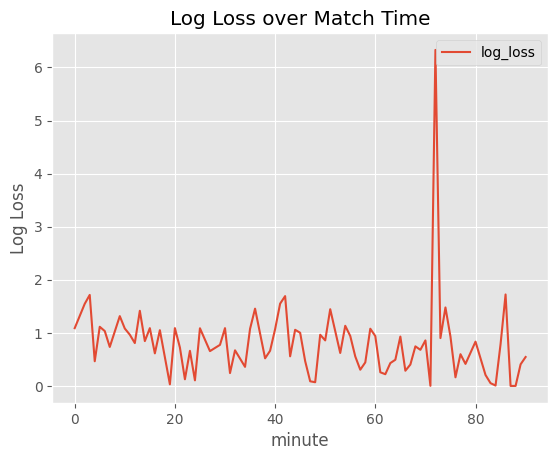

In [11]:
all_preds = []
for g in finished_games:
    actual = determine_outcome(g)
    for row in timelines[str(g["id"])]:
        all_preds.append({
            'minute': row['minute'],
            'p_home': row['p_home'],
            'p_draw': row['p_draw'],
            'p_away': row['p_away'],
            'actual': actual,
            'actual_idx': 2 if actual == 'home' else (1 if actual == 'draw' else 0)
        })

df_timeline = pd.DataFrame(all_preds)

def calculate_loss_by_minute(df):
    minutes = sorted(df['minute'].unique())
    losses = []
    for m in minutes:
        sub = df[df['minute'] == m]
        if len(sub) == 0: continue
        probs = sub[['p_away', 'p_draw', 'p_home']].values
        loss = log_loss(sub['actual_idx'], probs, labels=[0,1,2])
        losses.append({'minute': m, 'log_loss': loss})
    return pd.DataFrame(losses)

loss_df = calculate_loss_by_minute(df_timeline)
loss_df.plot(x='minute', y='log_loss', title='Log Loss over Match Time', ylabel='Log Loss')
plt.show()


---
## Test 6: Class-Specific Performance (Precision/Recall for Draws)
Confirming if the V2 model successfully handled draws over the whole tournament timeline.

In [12]:
df_timeline['predicted_idx'] = df_timeline[['p_away', 'p_draw', 'p_home']].values.argmax(axis=1)
print("Global Classification Report (all minutes combined):")
print(classification_report(df_timeline['actual_idx'], df_timeline['predicted_idx'], target_names=['Away', 'Draw', 'Home'], zero_division=0))


Global Classification Report (all minutes combined):
              precision    recall  f1-score   support

        Away       0.60      0.73      0.66       483
        Draw       0.32      0.31      0.31       405
        Home       0.76      0.69      0.72       964

    accuracy                           0.62      1852
   macro avg       0.56      0.57      0.56      1852
weighted avg       0.62      0.62      0.62      1852



---
## Test 7: Event Responsiveness (Goal Impact)
Look at the average probability swing immediately following a goal.

Average Win Probability increase after scoring: 0.179


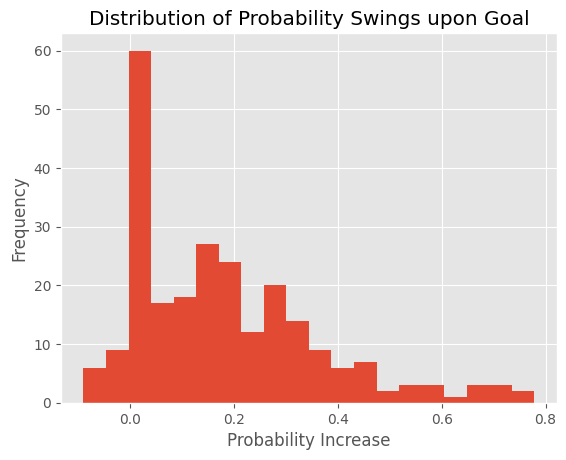

In [13]:
swings = []
for g in finished_games:
    match_id = str(g["id"])
    t = timelines[match_id]
    for i in range(1, len(t)):
        prev, curr = t[i-1], t[i]
        goal_scored = (curr['home_score'] > prev['home_score']) or (curr['away_score'] > prev['away_score'])
        if goal_scored:
            if curr['home_score'] > prev['home_score']:
                swing = curr['p_home'] - prev['p_home']
                team = "Home"
            else:
                swing = curr['p_away'] - prev['p_away']
                team = "Away"
            swings.append({'minute': curr['minute'], 'team_scored': team, 'prob_increase': swing})

df_swings = pd.DataFrame(swings)
if len(df_swings) > 0:
    print(f"Average Win Probability increase after scoring: {df_swings['prob_increase'].mean():.3f}")
    df_swings['prob_increase'].plot(kind='hist', bins=20, title='Distribution of Probability Swings upon Goal', xlabel='Probability Increase')
    plt.show()
else:
    print("No goals recorded to calculate swings.")
